# Cargar rápido una batería nueva la hace durar más

Toda la vida nos dijeron lo contrario: una batería nueva se "forma" cargándola **despacio** la primera vez, para no maltratarla. Este paper de *Nature* hizo justo lo prohibido —cargarla rápido— y la batería terminó con **20% más capacidad** y aguantando muchos más ciclos.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

---

**Paper:** *Fast formation to reinforce lithium-rich cathodes* — Fan et al., *Nature* (2026)
**DOI:** [10.1038/s41586-025-09553-3](https://doi.org/10.1038/s41586-025-09553-3)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-24-formacion-rapida-catodos-litio/notebook.ipynb)

**Video:** [Pendiente]

## ¿Qué es "formar" una batería?

Cuando sale una celda de litio de fábrica, no se vende de una. Pasa por la **formación**: las primeras cargas y descargas que construyen la capa protectora entre el electrodo y el electrolito. La regla de oro de la industria era hacerlo **lento** —y eso cuesta días de planta y plata.

El equipo trabajó con un cátodo **rico en litio** (LLO, por *lithium-rich layered oxide*): mucho litio para guardar energía, pero una red cristalina frágil. Cambiaron una sola perilla —la velocidad de esa primera carga, de 0.2C (lento) a 2C (diez veces más rápido)— y midieron 200 ciclos. La notación que verás: **LLO-formación/ciclado**, así que `LLO-2/0.2` es formación rápida, `LLO-0.2/0.2` es formación lenta.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
VENTAJA_PAPER = 20            # ventaja de capacidad reportada por el paper (%)
COLOR_RAPIDA   = '#2563EB'    # formación rápida, ciclado lento (LLO-2/0.2)
COLOR_RAPIDA2  = '#059669'    # formación rápida, ciclado rápido (LLO-2/2)
COLOR_LENTA    = '#D97706'    # formación lenta, ciclado lento (LLO-0.2/0.2)
COLOR_LENTA2   = '#DC2626'    # formación lenta, ciclado rápido (LLO-0.2/2)
FUENTE = 'Fuente: Fan et al. (2026), Nature | Datos: Source Data Fig. 1 (mismo DOI)'

import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de los 3 archivos de Source Data (Fig. 1 del paper)
ciclado   = pd.read_csv('datos/fig1e_ciclado.csv')        # capacidad vs ciclo, 4 condiciones
irrev     = pd.read_csv('datos/fig1d_irrev_ce.csv')       # pérdida irreversible + eficiencia 1er ciclo
formacion = pd.read_csv('datos/fig1b_carga_inicial.csv')  # perfil de la carga de formación

# Mapa condición -> (etiqueta legible, color)
ESTILO = {
    'LLO-2/0.2':   ('Formación rápida',          COLOR_RAPIDA),
    'LLO-2/2':     ('Formación rápida (ciclo 2C)', COLOR_RAPIDA2),
    'LLO-0.2/0.2': ('Formación lenta',           COLOR_LENTA),
    'LLO-0.2/2':   ('Formación lenta (ciclo 2C)',  COLOR_LENTA2),
}

print(f'Ciclado: {ciclado["condicion"].nunique()} condiciones x {ciclado["ciclo"].max()} ciclos')
print(f'Condiciones: {sorted(ciclado["condicion"].unique())}')
print()
print('Retención a 200 ciclos (capacidad final / capacidad inicial):')
for cond in ['LLO-2/0.2', 'LLO-2/2', 'LLO-0.2/0.2', 'LLO-0.2/2']:
    s = ciclado[ciclado['condicion'] == cond].sort_values('ciclo')
    ret = s.iloc[-1]['capacidad_mAhg'] / s.iloc[0]['capacidad_mAhg'] * 100
    print(f'  {cond:12s} {ESTILO[cond][0]:28s} {ret:5.1f}%')

Ciclado: 4 condiciones x 200 ciclos
Condiciones: ['LLO-0.2/0.2', 'LLO-0.2/2', 'LLO-2/0.2', 'LLO-2/2']

Retención a 200 ciclos (capacidad final / capacidad inicial):
  LLO-2/0.2    Formación rápida              98.4%
  LLO-2/2      Formación rápida (ciclo 2C)   97.1%
  LLO-0.2/0.2  Formación lenta               87.3%
  LLO-0.2/2    Formación lenta (ciclo 2C)    85.3%


## Aquí está.

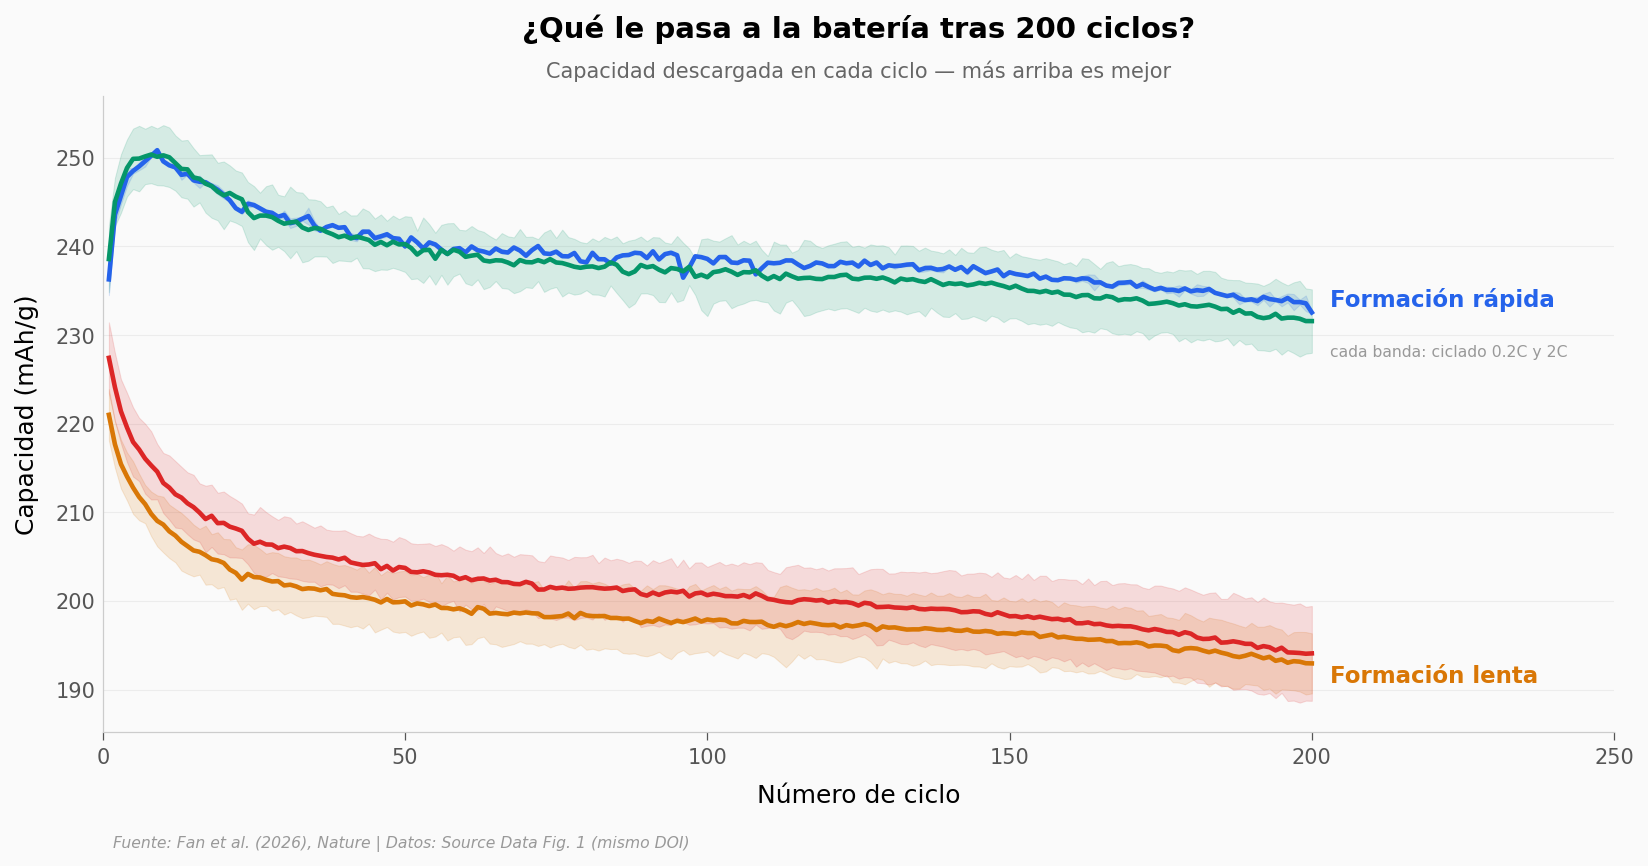

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

orden = ['LLO-2/0.2', 'LLO-2/2', 'LLO-0.2/0.2', 'LLO-0.2/2']
y_final = {}
for cond in orden:
    _, color = ESTILO[cond]
    s = ciclado[ciclado['condicion'] == cond].sort_values('ciclo')
    x, y, sd = s['ciclo'].values, s['capacidad_mAhg'].values, s['desviacion_std'].values
    ax.plot(x, y, color=color, linewidth=2.2, zorder=5)
    ax.fill_between(x, y - sd, y + sd, color=color, alpha=0.15, zorder=2)
    y_final[cond] = y[-1]

# Las 4 curvas forman dos bandas (rápida arriba, lenta abajo): etiquetar la banda,
# no cada curva. Cada banda agrupa los dos ritmos de ciclado (0.2C y 2C).
ax.text(203, (y_final['LLO-2/0.2'] + y_final['LLO-2/2']) / 2 + 2,
        'Formación rápida', fontsize=11, color=COLOR_RAPIDA, fontweight='bold', va='center')
ax.text(203, (y_final['LLO-0.2/0.2'] + y_final['LLO-0.2/2']) / 2 - 2,
        'Formación lenta', fontsize=11, color=COLOR_LENTA, fontweight='bold', va='center')
ax.text(203, (y_final['LLO-2/0.2'] + y_final['LLO-2/2']) / 2 - 4,
        'cada banda: ciclado 0.2C y 2C', fontsize=7.5, color='#999999', va='center')

ax.set_title('¿Qué le pasa a la batería tras 200 ciclos?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Capacidad descargada en cada ciclo — más arriba es mejor',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Número de ciclo')
ax.set_ylabel('Capacidad (mAh/g)')
ax.set_xlim(0, 250)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/ciclado_4_condiciones.png', dpi=200, bbox_inches='tight')
plt.show()

Las dos curvas de **formación rápida** se quedan arriba, casi planas: terminan reteniendo **98% y 97%** de su capacidad. Las de **formación lenta** se desploman —caen a **87% y 85%**—. Y fíjate en algo: al principio las cuatro arrancan cerca. La distancia no estaba al inicio; **se abre con el uso**. Lo que decidiste en la primera carga se cobra (o se paga) ciclo a ciclo.

## ¿Por qué la rápida aguanta más?

La pista está en el **primer ciclo**. Parte del litio que sale del cátodo en esa carga inicial nunca vuelve —es la **capacidad irreversible**, litio perdido para siempre—. Veamos cuánto pierde cada condición.

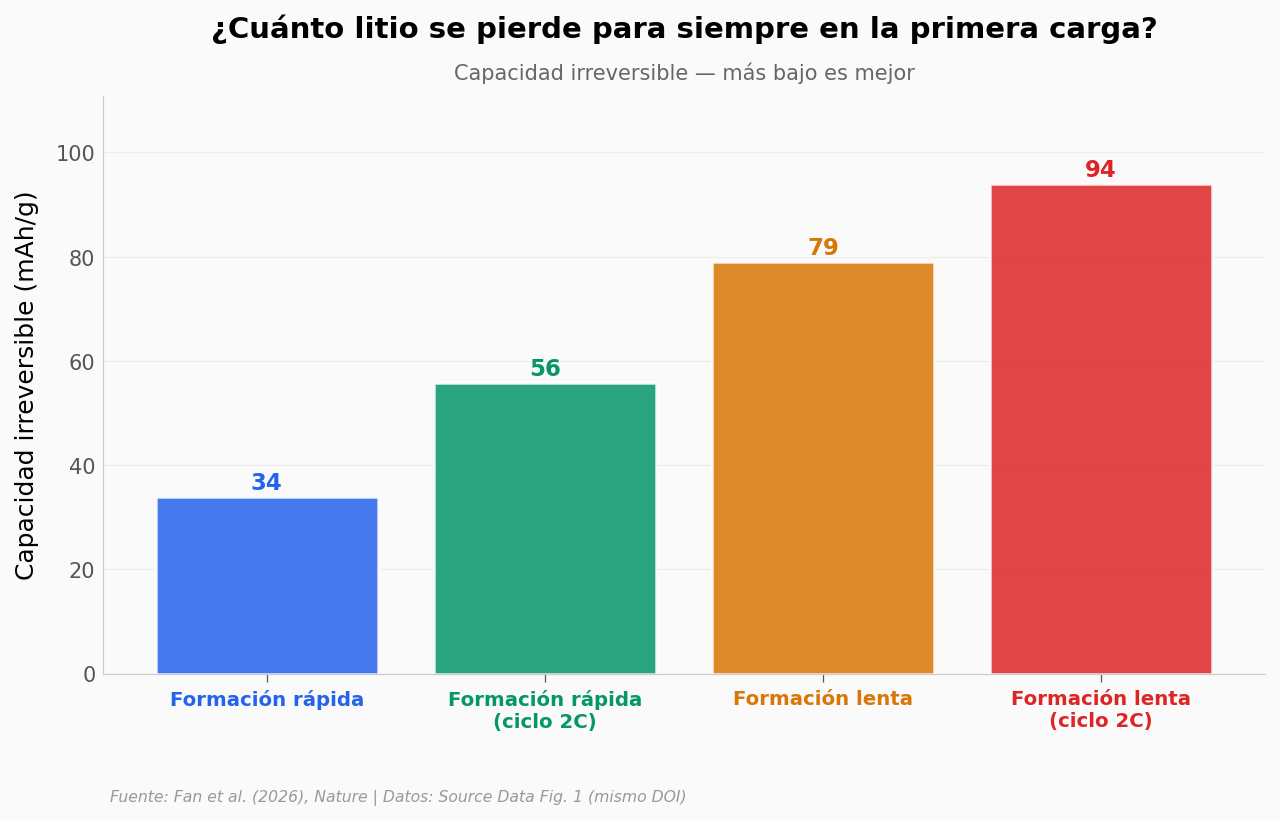

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))

orden = ['LLO-2/0.2', 'LLO-2/2', 'LLO-0.2/0.2', 'LLO-0.2/2']
valores  = [irrev[irrev['condicion'] == c]['capacidad_irreversible_mAhg'].iloc[0] for c in orden]
colores  = [ESTILO[c][1] for c in orden]
etiquetas = [ESTILO[c][0].replace(' (ciclo 2C)', '\n(ciclo 2C)') for c in orden]

barras = ax.bar(range(len(orden)), valores, color=colores, alpha=0.85,
                edgecolor='white', linewidth=1.2, zorder=5)
for i, v in enumerate(valores):
    ax.text(i, v + 1.5, f'{v:.0f}', ha='center', fontsize=11,
            fontweight='bold', color=colores[i])

ax.set_title('¿Cuánto litio se pierde para siempre en la primera carga?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Capacidad irreversible — más bajo es mejor',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xticks(range(len(orden)))
ax.set_xticklabels(etiquetas, fontsize=9.5, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), colores):
    tick.set_color(color)
ax.set_ylabel('Capacidad irreversible (mAh/g)')
ax.set_ylim(0, max(valores) * 1.18)

fig.text(0.13, -0.06, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/capacidad_irreversible.png', dpi=200, bbox_inches='tight')
plt.show()

La formación rápida pierde **menos de la mitad** de litio que la lenta (34 vs 79 mAh/g en el ciclado suave). Ese litio que se queda no es pasivo: el paper lo describe como un **efecto de anclaje** (*self-pinning*) que sujeta la red cristalina y evita que se deforme. La otra cara de la misma moneda es la **eficiencia del primer ciclo** (eficiencia coulómbica): qué fracción de lo que metiste, recuperas.

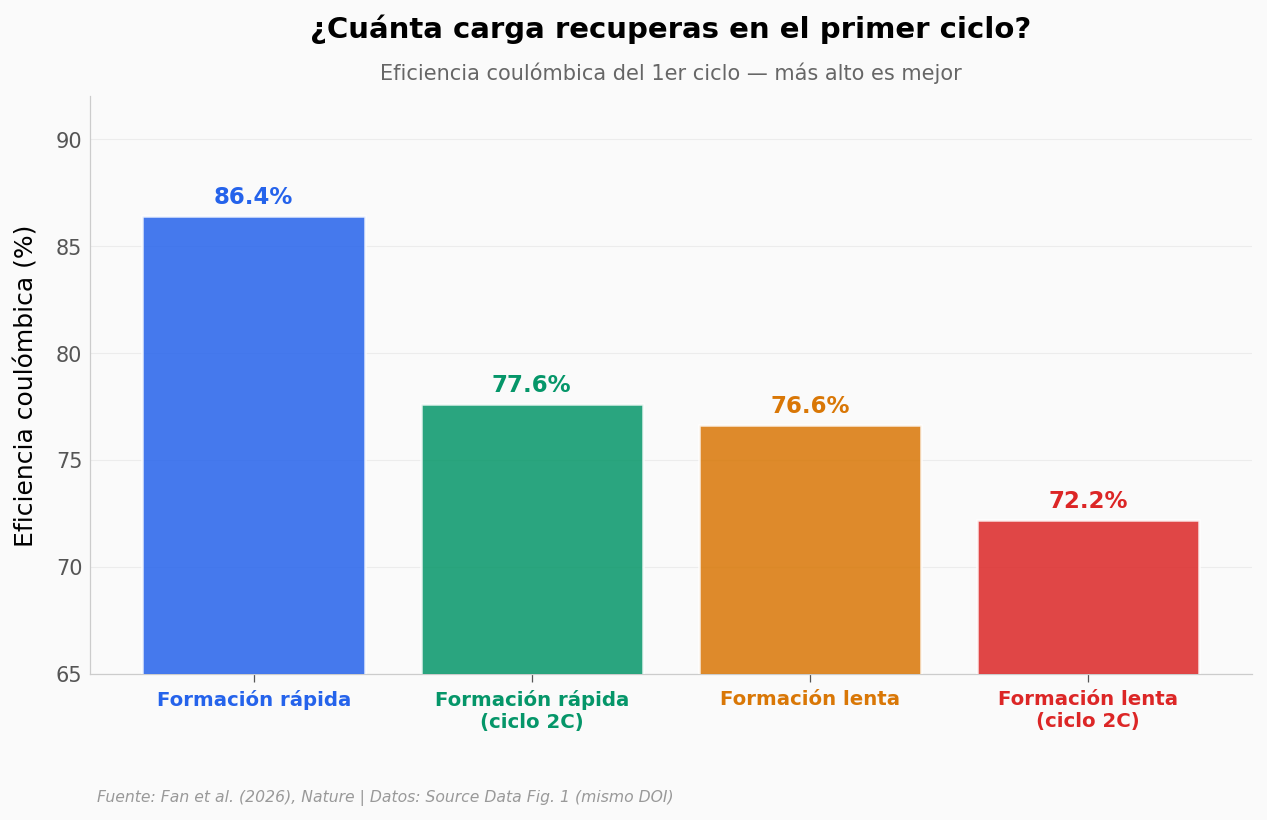

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

orden = ['LLO-2/0.2', 'LLO-2/2', 'LLO-0.2/0.2', 'LLO-0.2/2']
valores  = [irrev[irrev['condicion'] == c]['eficiencia_coulombica_pct'].iloc[0] for c in orden]
colores  = [ESTILO[c][1] for c in orden]
etiquetas = [ESTILO[c][0].replace(' (ciclo 2C)', '\n(ciclo 2C)') for c in orden]

ax.bar(range(len(orden)), valores, color=colores, alpha=0.85,
       edgecolor='white', linewidth=1.2, zorder=5)
for i, v in enumerate(valores):
    ax.text(i, v + 0.6, f'{v:.1f}%', ha='center', fontsize=11,
            fontweight='bold', color=colores[i])

ax.set_title('¿Cuánta carga recuperas en el primer ciclo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Eficiencia coulómbica del 1er ciclo — más alto es mejor',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xticks(range(len(orden)))
ax.set_xticklabels(etiquetas, fontsize=9.5, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), colores):
    tick.set_color(color)
ax.set_ylabel('Eficiencia coulómbica (%)')
ax.set_ylim(65, 92)

fig.text(0.13, -0.06, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/eficiencia_primer_ciclo.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Y si la ventaja fuera casualidad de un ciclo suelto?

La ventaja de capacidad de la formación rápida no es de un ciclo con suerte. Calculemos, ciclo por ciclo, cuánto le gana la rápida a la lenta (con el mismo ciclado de 0.2C) a lo largo de los 200 ciclos, y miremos la distribución completa.

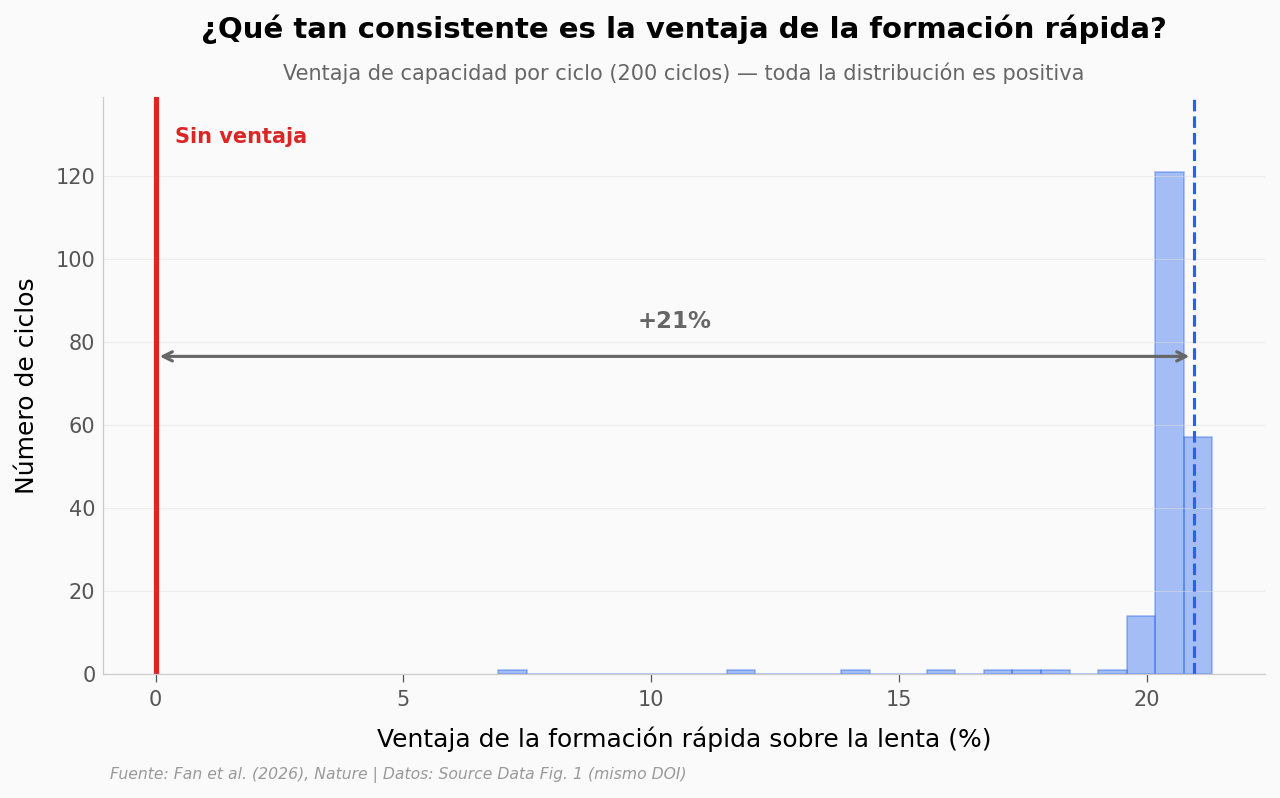

Ventaja en el ciclo 1:  +6.9%
Ventaja final (media últimos 10 ciclos): +20.9%
En los 200 ciclos la ventaja nunca fue negativa: True


In [5]:
# Ventaja por ciclo: formación rápida vs lenta (mismo ciclado 0.2C)
rapida = ciclado[ciclado['condicion'] == 'LLO-2/0.2'].set_index('ciclo')['capacidad_mAhg']
lenta  = ciclado[ciclado['condicion'] == 'LLO-0.2/0.2'].set_index('ciclo')['capacidad_mAhg']
comun = rapida.index.intersection(lenta.index)
ventaja = (rapida[comun] - lenta[comun]) / lenta[comun] * 100   # % por ciclo

ventaja_inicial = ventaja.loc[1]
ventaja_final = ventaja.loc[comun.max() - 9:].mean()            # media últimos 10 ciclos

fig, ax = plt.subplots(figsize=(10, 5))
n, bins, patches = ax.hist(ventaja.values, bins=25, color=COLOR_RAPIDA, alpha=0.4,
                           edgecolor=COLOR_RAPIDA, linewidth=0.8)
y_max = n.max() * 1.15
ax.set_ylim(0, y_max)

# Línea en 0 = sin ventaja; toda la distribución queda a la derecha
ax.axvline(x=0, color='#DC2626', linewidth=2.5)
ax.text(0.4, y_max * 0.92, 'Sin ventaja', color='#DC2626', fontsize=10, fontweight='bold')

ax.axvline(x=ventaja_final, color=COLOR_RAPIDA, linewidth=1.5, linestyle='--')
ax.annotate('', xy=(ventaja_final, y_max * 0.55), xytext=(0, y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(ventaja_final / 2, y_max * 0.60, f'+{ventaja_final:.0f}%',
        ha='center', fontsize=11, fontweight='bold', color='#666666')

ax.set_title('¿Qué tan consistente es la ventaja de la formación rápida?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Ventaja de capacidad por ciclo (200 ciclos) — toda la distribución es positiva',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Ventaja de la formación rápida sobre la lenta (%)')
ax.set_ylabel('Número de ciclos')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_ventaja.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Ventaja en el ciclo 1:  +{ventaja_inicial:.1f}%')
print(f'Ventaja final (media últimos 10 ciclos): +{ventaja_final:.1f}%')
print(f'En los 200 ciclos la ventaja nunca fue negativa: {(ventaja > 0).all()}')

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| La formación rápida mejora la capacidad reversible ~20% | ✅ | +20.9% (ciclado 0.2C) y +19.3% (ciclado 2C), medido como media de los últimos 10 ciclos. Coincide con el titular del paper. |
| La ventaja **crece** con el ciclado, no es de salida | ✅ | En el ciclo 1 la ventaja es solo +6.9%; sube a +20.9% al final. La distribución de los 200 ciclos es positiva en todos. |
| La formación rápida pierde menos litio irreversible | ✅ | 34 vs 79 mAh/g (ciclado 0.2C); 56 vs 94 mAh/g (ciclado 2C). Eficiencia del 1er ciclo más alta (86.4% vs 76.6%). |
| Mejor retención tras 200 ciclos | ✅ | Rápida: 98.4% y 97.1%. Lenta: 87.3% y 85.3%. |
| "+36% de vida útil" | ⚠️ | Es el titular del paper, **no reproducible en este panel**: ninguna condición baja del 80% de retención en 200 ciclos. Probable extrapolación con un umbral de fin de vida propio del estudio. |
| El "efecto de anclaje" (*self-pinning*) del litio residual | ⚠️ | Mecanismo descrito por el paper con sincrotrón (Figs. 2–4). Aquí mostramos su **consecuencia** (menos pérdida, más retención), no el mecanismo directo. |
| "Se puede extender a otros electrodos" | ⚠️ | El paper lo plantea como posibilidad a futuro, no como resultado medido. |

> **Limitaciones:** los datos provienen de celdas tipo moneda en laboratorio (no celdas comerciales). El panel cubre 200 ciclos; el "+36%" del titular no se puede verificar con estos datos. El mecanismo (litio residual anclando la red) se ve por sincrotrón en otras figuras del paper, no en estas series.

## Ahora tú

1. **¿Cómo se ve la carga de formación misma?** El archivo `fig1b_carga_inicial.csv` tiene el perfil de voltaje de esa primera carga (potencial vs litio que sale del cátodo) para rápida y lenta. La celda de abajo lo grafica —¿en qué se diferencian las dos curvas?
2. **¿Y si comparas con ciclado a 2C?** Cambia `'LLO-2/0.2'` y `'LLO-0.2/0.2'` por `'LLO-2/2'` y `'LLO-0.2/2'` en la celda de la distribución. ¿La ventaja sigue siendo positiva en todos los ciclos?
3. **¿En qué ciclo la ventaja supera el 15%?** Con la serie `ventaja` de la celda anterior, prueba `ventaja[ventaja > 15].index.min()`.

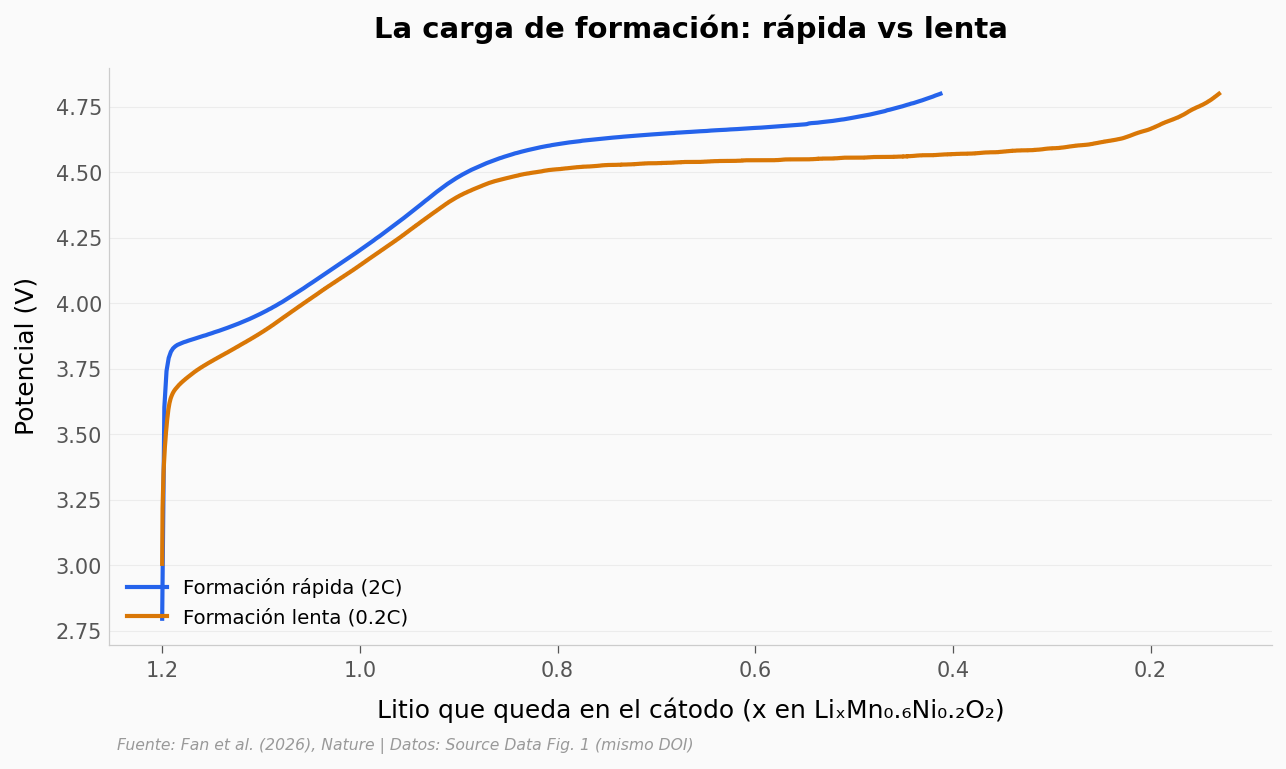

In [6]:
# --- EXPERIMENTA AQUÍ ---
# El perfil de la carga de formación: cómo sube el voltaje mientras
# se va sacando litio del cátodo (x baja de 1.2 hacia ~0.13).
fig, ax = plt.subplots(figsize=(10, 5))

mapa = {
    'LLO-2/0.2 (formacion rapida)': ('Formación rápida (2C)', COLOR_RAPIDA),
    'LLO-0.2/0.2 (formacion lenta)': ('Formación lenta (0.2C)', COLOR_LENTA),
}
for cond, (etiqueta, color) in mapa.items():
    s = formacion[formacion['condicion'] == cond].sort_values('x_en_LixMn06Ni02O2', ascending=False)
    ax.plot(s['x_en_LixMn06Ni02O2'], s['potencial_V'], color=color, linewidth=2, label=etiqueta)

ax.invert_xaxis()  # el litio se va saliendo: x decrece durante la carga
ax.set_title('La carga de formación: rápida vs lenta',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Litio que queda en el cátodo (x en LiₓMn₀.₆Ni₀.₂O₂)')
ax.set_ylabel('Potencial (V)')
ax.legend(fontsize=9.5, loc='lower left', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/perfil_formacion.png', dpi=200, bbox_inches='tight')
plt.show()

---

## Fuentes

**Paper**: [Fast formation to reinforce lithium-rich cathodes](https://doi.org/10.1038/s41586-025-09553-3)  
*Nature, 2026-06-17*

**Source Data**: [Source Data Fig. 1 (MOESM2, mismo DOI)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-025-09553-3/MediaObjects/41586_2025_9553_MOESM2_ESM.xlsx)

*15 afirmaciones verificadas contra estas fuentes*

---

*Notebook reproducible de [Ciencia a Mordiscos](https://cienciaamordiscos.com). Datos abiertos del Source Data del paper. Licencia del análisis: MIT. Repo: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab).*